# 07 — Satış ve Dolum Analizi

`transactions.csv` ve `deliveries.csv` — pompa decimal, test satışı, hayali/algılanmayan dolum sinyalleri.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all
from utils.plots import setup_style

setup_style()
dfs = load_all()
tx = dfs['transactions']
deliv = dfs['deliveries']

In [2]:
# Satış istatistikleri
print('Toplam işlem:', len(tx))
print('Test satışı:', tx['test_satisi'].sum())
print('Satış tipi:', tx['satis_tipi'].value_counts().to_dict())
print('Litre istatistikleri:')
print(tx['litre'].describe())

Toplam işlem: 231874
Test satışı: 6
Satış tipi: {'Pompaci': 197247, 'Kendin Sec': 34627}
Litre istatistikleri:
count    231411.000000
mean         36.845774
std          27.768697
min           3.940000
25%          17.680000
50%          30.520000
75%          48.990000
max        1600.000000
Name: litre, dtype: float64


In [3]:
# Pompa decimal adayı: litre vs tutar/birim_fiyat
tx_ok = tx.dropna(subset=['litre','tutar','birim_fiyat'])
tx_ok = tx_ok[tx_ok['birim_fiyat'] > 0]
tx_ok['litre_hesap'] = tx_ok['tutar'] / tx_ok['birim_fiyat']
tx_ok['litre_oran'] = tx_ok['litre'] / tx_ok['litre_hesap']

# 10x sapma
decimal = tx_ok[(tx_ok['litre_oran'] > 5) | (tx_ok['litre_oran'] < 0.2)]
print('Decimal şüpheli işlem:', len(decimal))
if len(decimal):
    display(decimal.groupby(['istasyon_kodu','tank_no']).size().sort_values(ascending=False).head())

Decimal şüpheli işlem: 122


istasyon_kodu  tank_no
IST_007        1.0        122
dtype: int64

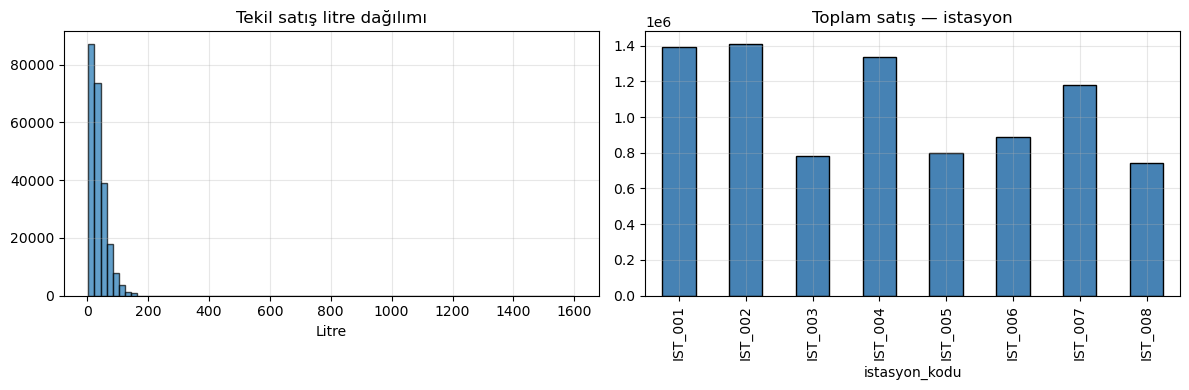

In [4]:
# İşlem büyüklüğü dağılımı
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tx['litre'].hist(bins=80, ax=axes[0], edgecolor='k', alpha=0.7)
axes[0].set_xlabel('Litre'); axes[0].set_title('Tekil satış litre dağılımı')
tx.groupby('istasyon_kodu')['litre'].sum().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='k')
axes[1].set_title('Toplam satış — istasyon')
plt.tight_layout()
plt.show()

In [5]:
# Dolum analizi
print('Toplam dolum kaydı:', len(deliv))
print('Dolum net istatistikleri:')
print(deliv['dolum_net'].describe())

deliv['tarih'] = deliv['dolum_baslangic'].dt.normalize()
dolum_gun = deliv.groupby(['istasyon_kodu','tank_no','tarih'])['dolum_net'].sum().reset_index()
print('\nEn büyük dolumlar:')
display(dolum_gun.nlargest(10, 'dolum_net'))

Toplam dolum kaydı: 1109
Dolum net istatistikleri:
count     1109.000000
mean      7604.616619
std       2758.825021
min       3407.660000
25%       4862.420000
50%       7461.680000
75%       9646.930000
max      12994.520000
Name: dolum_net, dtype: float64

En büyük dolumlar:


,istasyon_kodu,tank_no,tarih,dolum_net
630,IST_005,1,2026-01-11,17356.93
176,IST_001,5,2026-03-27,16847.84
1020,IST_008,1,2026-02-06,14698.39
340,IST_002,5,2026-03-10,14670.46
303,IST_002,5,2026-01-14,14215.29
694,IST_005,3,2026-01-02,12994.52
860,IST_007,1,2026-01-20,12981.96
649,IST_005,1,2026-02-16,12979.52
141,IST_001,5,2026-01-28,12972.47
876,IST_007,1,2026-02-18,12966.21


In [6]:
# Dolum sonrası envanter artışı vs kayıtlı dolum — ue1t join
ue1t = dfs['ue1t_30min']
dolum_donem = ue1t[ue1t['tanka_dolum'] > 100][['saat_1','istasyon_kodu','tank_no','tanka_dolum','kayip_kazanc']]
print('UE1T dolumlu dönem (>100 lt):', len(dolum_donem))
display(dolum_donem.nlargest(10, 'tanka_dolum'))

UE1T dolumlu dönem (>100 lt): 1109


,saat_1,istasyon_kodu,tank_no,tanka_dolum,kayip_kazanc
78017,2026-01-02 18:30:00,IST_005,3,12994.52,-30.48
111778,2026-01-20 17:00:00,IST_007,1,12981.96,-40.96
84477,2026-02-16 15:30:00,IST_005,1,12979.52,49.90
6589,2026-01-28 10:30:00,IST_001,5,12972.47,-44.40
117322,2026-02-18 19:00:00,IST_007,1,12966.21,-39.20
61302,2026-01-22 10:00:00,IST_004,3,12964.69,22.66
10814,2026-02-15 01:00:00,IST_001,5,12963.08,56.22
60260,2026-01-18 02:00:00,IST_004,1,12950.70,45.39
72437,2026-03-09 19:30:00,IST_004,3,12942.30,34.24
16989,2026-03-12 18:30:00,IST_001,5,12929.94,-42.85


Sonraki: manifold ve bölmeli tanklar (`08_manifold_bolmeli.ipynb`).